In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install vaderSentiment pandas matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import os

analyzer = SentimentIntensityAnalyzer()
os.makedirs('/content/drive/MyDrive/CAPSTONE_DATA/outputs', exist_ok=True)
print(" Ready!")

 Ready!


In [11]:
reddit = pd.read_csv('/content/drive/MyDrive/CAPSTONE_DATA/reddit/final_reddit_posts.csv')
print(f"Shape: {reddit.shape}")
print(reddit.columns.tolist())
print(reddit.head(3))

Shape: (1397, 14)
['influencer_name', 'title', 'text', 'subreddit', 'author', 'score', 'upvote_ratio', 'num_comments', 'published_at', 'url', 'date', 'hour', 'day_of_week', 'full_text']
           influencer_name                                              title  \
0                   HASfit                    What is your opinion of HASfit?   
1  Body Fitness Motivation  [Transformation Pics] 250-190lbs (5'11/M/18) F...   
2         HOME WORKOUT 2.0  Home made pre-workout! Only $0.60/serving vers...   

                                                text subreddit  \
0  Specifically this [routine](http://hasfit.com/...   Fitness   
1  http://i.imgur.com/V3klyKj.jpg\n\nI've had an ...   Fitness   
2  I realized that since 1,2-dimethylamylamine (D...    Frugal   

            author  score  upvote_ratio  num_comments  \
0         Retsejme      2          0.75             2   
1             23x3   1551          0.92           337   
2  Winter1sCumming    384          0.82           211

In [12]:
# Use full_text if available, fallback to text
reddit['text_to_analyze'] = reddit['full_text'].fillna(reddit['text'])
reddit = reddit.dropna(subset=['text_to_analyze'])
reddit = reddit[reddit['text_to_analyze'].str.strip() != '']
reddit['text_to_analyze'] = reddit['text_to_analyze'].astype(str)

print(f" Clean rows: {len(reddit)}")

 Clean rows: 1397


In [13]:
def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        label = 'positive'
    elif compound <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'
    return pd.Series([compound, label, scores['pos'], scores['neg'], scores['neu']])

reddit[['compound', 'sentiment', 'pos', 'neg', 'neu']] = reddit['text_to_analyze'].apply(get_sentiment)

print(" Sentiment done!")
print(reddit['sentiment'].value_counts())
print(f"\nAvg compound score: {reddit['compound'].mean():.3f}")

 Sentiment done!
sentiment
positive    953
negative    275
neutral     169
Name: count, dtype: int64

Avg compound score: 0.409


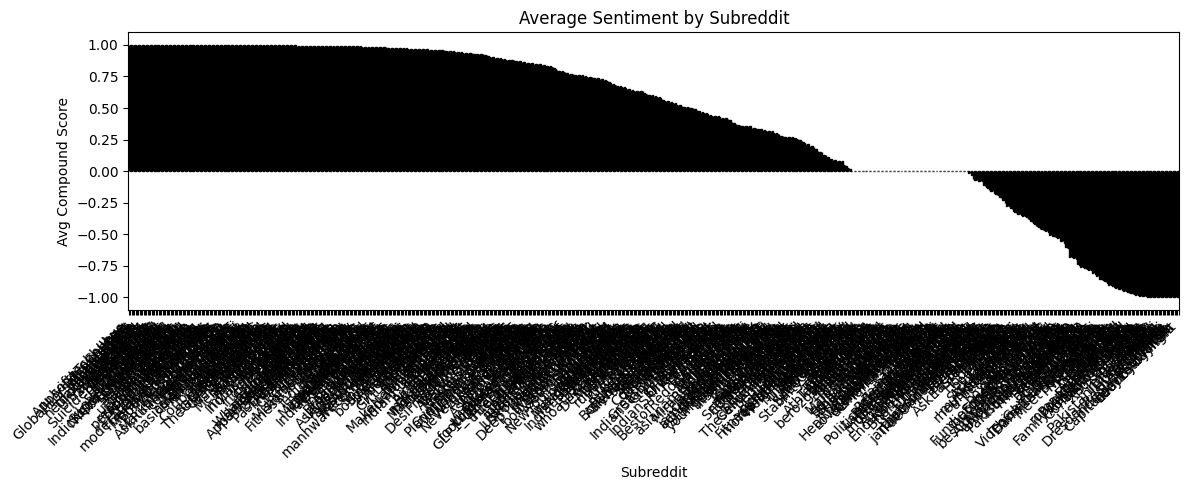

In [14]:
subreddit_sentiment = reddit.groupby('subreddit')['compound'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
subreddit_sentiment.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Sentiment by Subreddit')
plt.xlabel('Subreddit')
plt.ylabel('Avg Compound Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CAPSTONE_DATA/outputs/reddit_subreddit_sentiment.png')
plt.show()

In [15]:
influencer_sentiment = reddit.groupby('influencer_name')['compound'].mean().sort_values(ascending=False)

print("=== Top 10 Most Positively Discussed Influencers ===")
print(influencer_sentiment.head(10))
print("\n=== Top 10 Most Negatively Discussed ===")
print(influencer_sentiment.tail(10))

=== Top 10 Most Positively Discussed Influencers ===
influencer_name
Anita yoga fitness                   0.995522
Rhea Yoga & Fitness                  0.986600
Indian Fitness Motivation            0.979150
testRunner - running shoe reviews    0.973760
Indian 🇮🇳 fitness 555                0.964010
Yoga Fitness Mania                   0.953950
JOGGERS JOURNAL (Hindi)              0.938200
Best Shoes Review                    0.912722
Trail Shoes Reviewed                 0.903844
akshay Indian fitness                0.880390
Name: compound, dtype: float64

=== Top 10 Most Negatively Discussed ===
influencer_name
Will Tennyson                        -0.042467
Afton Fitness India                  -0.056840
BurpeeGirl                           -0.066580
NL Fitness                           -0.104429
Kingdom of Fitness                   -0.173817
Foothunk                             -0.204933
Kathy Smith                          -0.214171
Indian fitness 777                   -0.242378
Allen 

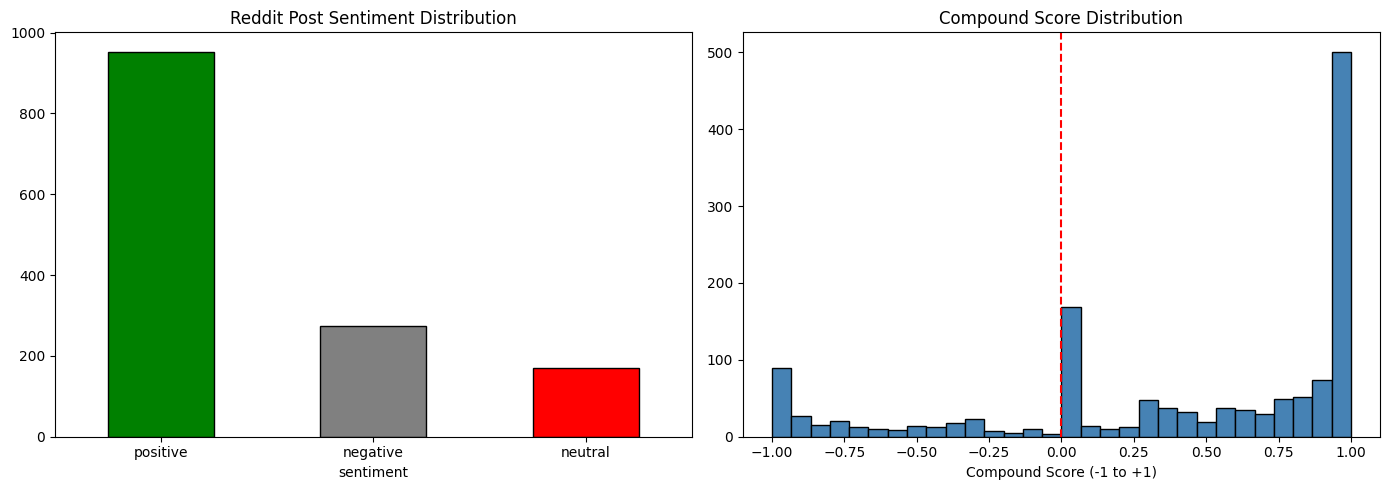

 Plot saved!


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reddit['sentiment'].value_counts().plot(kind='bar', ax=axes[0],
    color=['green', 'gray', 'red'], edgecolor='black')
axes[0].set_title('Reddit Post Sentiment Distribution')
axes[0].tick_params(axis='x', rotation=0)

axes[1].hist(reddit['compound'], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Compound Score Distribution')
axes[1].set_xlabel('Compound Score (-1 to +1)')
axes[1].axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CAPSTONE_DATA/outputs/reddit_sentiment_plot.png')
plt.show()
print(" Plot saved!")

In [17]:
output_cols = ['influencer_name', 'title', 'text_to_analyze', 'subreddit',
               'score', 'published_at', 'compound', 'sentiment', 'pos', 'neg', 'neu']

# Keep only columns that exist
output_cols = [c for c in output_cols if c in reddit.columns]

reddit[output_cols].to_csv(
    '/content/drive/MyDrive/CAPSTONE_DATA/outputs/reddit_with_sentiment.csv',
    index=False
)
print(f" Saved! Shape: {reddit.shape}")
print(reddit['sentiment'].value_counts())

 Saved! Shape: (1397, 20)
sentiment
positive    953
negative    275
neutral     169
Name: count, dtype: int64
